# 09 — Robust Data Preprocessing Pipeline

Systematically improves the LGBM feature matrix with five steps:

| Step | What | Why |
|---|---|---|
| 1 | Remove high-SE labels | 358 compounds with SE > 0.5 add noise without signal |
| 2 | Clip feature outliers | Extreme RDKit descriptor values break gradient boosting splits |
| 3 | Feature selection | Remove zero-variance + >0.95-correlated descriptors |
| 4 | Upsample actives | 1.6% hit rate → model barely sees actives; random oversample to ~10% |
| 5 | Pseudo-inactive augmentation | Single-conc low-FC compounds → confident inactives at no labelling cost |

Saves processed data and a fitted `FeatureSelector` for downstream notebooks.

In [1]:
# ── 1. Setup ──────────────────────────────────────────────────────────────────
import sys, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb

from pxr.data import load_train, load_single_conc
from pxr.chem import to_inchikey
from pxr.featurize import combined, impute
from pxr.eval import scaffold_kfold_indices, compute_metrics, rae
from pxr.preprocess import (
    remove_label_outliers,
    clip_feature_outliers,
    FeatureSelector,
    upsample_by_category,
    category_sample_weights,
    pseudo_inactive_augment,
)
from pxr.paths import DATA_PROCESSED, FIGURES
from pxr.chem import bemis_murcko

plt.rcParams.update({"figure.dpi": 120})
print("Libraries loaded.")

Libraries loaded.


Raw training rows: 4,139
pEC50 range: 1.61 – 7.55
pEC50 mean±std: 4.321 ± 1.122

Label outlier scan:
  |z| > 3.0: 0 compounds
  |z| > 4.0: 0 compounds

SE distribution:
  SE > 0.3: 619 (15.0%)
  SE > 0.5: 358 (8.6%)
  SE > 0.75: 0 (0.0%)
  SE > 1.0: 0 (0.0%)


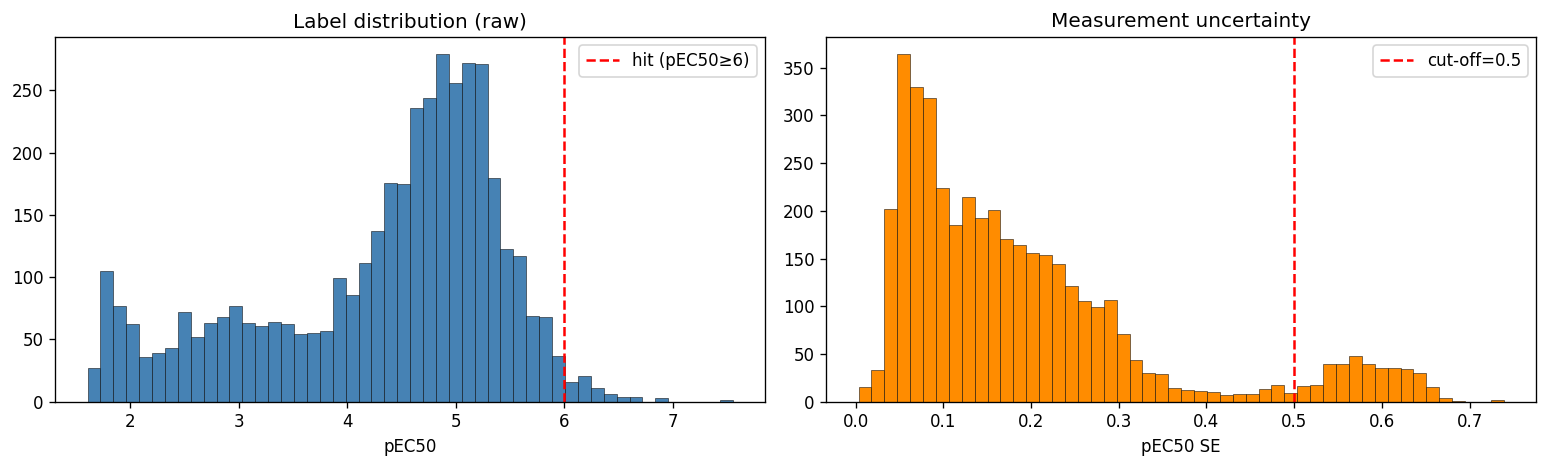

In [2]:
# ── 2. Load training data & show label distribution ───────────────────────────
raw = load_train()
print(f"Raw training rows: {len(raw):,}")
print(f"pEC50 range: {raw['pec50'].min():.2f} – {raw['pec50'].max():.2f}")
print(f"pEC50 mean±std: {raw['pec50'].mean():.3f} ± {raw['pec50'].std():.3f}")
print()

z = (raw['pec50'] - raw['pec50'].mean()) / raw['pec50'].std()
print("Label outlier scan:")
for thresh in [3.0, 4.0]:
    print(f"  |z| > {thresh}: {(z.abs() > thresh).sum()} compounds")
print()
print("SE distribution:")
for t in [0.3, 0.5, 0.75, 1.0]:
    print(f"  SE > {t}: {(raw['pec50_se'] > t).sum()} ({100*(raw['pec50_se']>t).mean():.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(raw['pec50'], bins=50, color='steelblue', edgecolor='k', lw=0.3)
axes[0].axvline(6.0, color='red', lw=1.5, linestyle='--', label='hit (pEC50≥6)')
axes[0].set(xlabel='pEC50', title='Label distribution (raw)')
axes[0].legend()
axes[1].hist(raw['pec50_se'], bins=50, color='darkorange', edgecolor='k', lw=0.3)
axes[1].axvline(0.5, color='red', lw=1.5, linestyle='--', label='cut-off=0.5')
axes[1].set(xlabel='pEC50 SE', title='Measurement uncertainty')
axes[1].legend()
plt.tight_layout()
plt.savefig(FIGURES / '09_label_distribution.png', bbox_inches='tight')
plt.show()

In [3]:
# ── 3. Remove label outliers (SE > 0.5) ───────────────────────────────────────
clean = remove_label_outliers(raw, max_se=0.5)

print(f"\nHit rate before: {(raw['pec50']>=6).mean():.2%}")
print(f"Hit rate after:  {(clean['pec50']>=6).mean():.2%}")
print(f"Mean SE before: {raw['pec50_se'].mean():.4f}")
print(f"Mean SE after:  {clean['pec50_se'].mean():.4f}")

remove_label_outliers: 4,139 -> 3,781 rows (removed 358: SE>0.5=358)

Hit rate before: 1.62%
Hit rate after:  1.77%
Mean SE before: 0.1918
Mean SE after:  0.1545


In [4]:
# ── 4. Compute combined features on cleaned data ──────────────────────────────
print("Computing combined features (Morgan + RDKit) ...")
smiles_clean = clean['smiles'].tolist()
y_clean      = clean['pec50'].values

X_raw = combined(smiles_clean)
X_raw = impute(X_raw)
print(f"Feature matrix: {X_raw.shape}  ({X_raw.shape[1]} features, 2048 FP + {X_raw.shape[1]-2048} desc)")

Computing combined features (Morgan + RDKit) ...


Feature matrix: (3781, 2265)  (2265 features, 2048 FP + 217 desc)


In [5]:
# ── 5. Clip feature outliers in descriptor block ──────────────────────────────
X_clipped = clip_feature_outliers(X_raw, iqr_factor=5.0, fp_cols=2048)

# Show impact on most-extreme descriptors
desc_block = X_raw[:, 2048:]
desc_clip  = X_clipped[:, 2048:]
n_changed  = (desc_block != desc_clip).any(axis=0).sum()
frac_vals  = (desc_block != desc_clip).mean()
print(f"Clipping affected {n_changed} descriptor columns")
print(f"Fraction of individual values changed: {frac_vals:.4f}")

Clipping affected 138 descriptor columns
Fraction of individual values changed: 0.0212


In [6]:
# ── 6. Feature selection ──────────────────────────────────────────────────────
selector = FeatureSelector(var_thresh=0.01, corr_thresh=0.95, fp_cols=2048)
X_sel    = selector.fit_transform(X_clipped)

print(f"\nSelected {selector.n_features_out} features from {X_clipped.shape[1]}")

# Save selector for use in downstream notebooks
sel_path = DATA_PROCESSED / 'feature_selector.pkl'
with open(sel_path, 'wb') as f:
    pickle.dump(selector, f)
print(f"Saved selector to {sel_path}")

[FeatureSelector] Variance filter: 2265 -> 1002 (removed 1263)
[FeatureSelector] Correlation filter: 128 -> 111 descriptors (removed 17)
[FeatureSelector] Final: 985 features (from 2265; total removed 1280)

Selected 985 features from 2265
Saved selector to D:\Users\ashenoy00000\.windsurf\OpenADMET-pxr-challenge\data\processed\feature_selector.pkl


In [7]:
# ── 7. Pseudo-inactive augmentation from single-concentration data ─────────────
sc = load_single_conc()

# Compounds in single_conc but NOT in training set (by InChIKey)
train_iks = set(clean['smiles'].map(to_inchikey).dropna())
sc['inchikey'] = sc['smiles'].map(to_inchikey)
sc_novel = sc[~sc['inchikey'].isin(train_iks)].copy()

# Keep only high-confidence inactives: |log2FC| < 0.5, FDR > 0.3
sc_inactive = sc_novel[
    (sc_novel['log2_fc_estimate'].abs() < 0.5) &
    (sc_novel['fdr_bh'] > 0.3) &
    sc_novel['smiles'].notna()
].drop_duplicates(subset='inchikey')

print(f"Single-conc novel compounds:         {len(sc_novel):,}")
print(f"High-confidence inactives (|FC|<0.5, FDR>0.3): {len(sc_inactive):,}")

# Cap augmentation at 2× the cleaned training size to avoid diluting the signal
max_aug = min(len(sc_inactive), 2 * len(clean))
sc_aug_df = sc_inactive.sample(max_aug, random_state=42).reset_index(drop=True)
aug_smiles, aug_y = pseudo_inactive_augment(sc_aug_df['smiles'].tolist(), seed=42)

print(f"Using {len(aug_smiles):,} pseudo-inactive compounds")
print(f"Pseudo-inactive pEC50: {aug_y.min():.2f} – {aug_y.max():.2f} (mean {aug_y.mean():.3f})")

Single-conc novel compounds:         15,465
High-confidence inactives (|FC|<0.5, FDR>0.3): 4,402
Using 4,402 pseudo-inactive compounds
Pseudo-inactive pEC50: 3.42 – 5.00 (mean 4.296)


In [8]:
# ── 8. Compute features for pseudo-inactive compounds ─────────────────────────
print("Computing features for pseudo-inactive compounds ...")
X_aug_raw  = combined(aug_smiles)
X_aug_raw  = impute(X_aug_raw)
X_aug_clip = clip_feature_outliers(X_aug_raw, fp_cols=2048)
X_aug_sel  = selector.transform(X_aug_clip)

# Concatenate with cleaned training set
X_full = np.vstack([X_sel, X_aug_sel])
y_full = np.concatenate([y_clean, aug_y])
print(f"Augmented dataset: {X_full.shape}  (original {len(X_sel)} + pseudo-inactive {len(X_aug_sel)})")

Computing features for pseudo-inactive compounds ...


Augmented dataset: (8183, 985)  (original 3781 + pseudo-inactive 4402)


In [9]:
# ── 9. CV comparison: baseline vs augmented pipeline ──────────────────────────
# We compare three setups on the CLEANED training set (no pseudo-inactives in CV
# to keep folds consistent):  baseline / + feature-selection / + upsample

# Reference LGBM params from notebook 07
lgbm_params = dict(
    n_estimators=1000, num_leaves=64, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=0.1,
    min_child_samples=10, n_jobs=4, verbose=-1,
)

scaffolds = clean['smiles'].map(bemis_murcko).tolist()
splits = scaffold_kfold_indices(scaffolds, n_splits=5, seed=42)

# Recompute baseline features on the cleaned (SE-filtered) training set
X_base = combined(smiles_clean)
X_base = impute(X_base)

configs = {
    "baseline (cleaned)": (X_base,  y_clean, False),
    "+ clip + select":    (X_sel,   y_clean, False),
    "+ clip + select + upsample": (X_sel, y_clean, True),
}

cv_results = {}
for name, (X, y, do_upsample) in configs.items():
    oof = np.full(len(y), np.nan)
    for tr_idx, va_idx in splits:
        X_tr, y_tr = X[tr_idx], y[tr_idx]
        if do_upsample:
            X_tr, y_tr = upsample_by_category(X_tr, y_tr, target_active_frac=0.10)
        m = lgb.LGBMRegressor(**lgbm_params)
        m.fit(X_tr, y_tr)
        oof[va_idx] = m.predict(X[va_idx])
    cv_results[name] = rae(y, oof)
    print(f"  {name:40s}  OOF RAE = {cv_results[name]:.4f}")

print(f"\n  (reference) LGBM_aug from notebook 07:          OOF RAE = 0.5582")

  baseline (cleaned)                        OOF RAE = 0.6116


  + clip + select                           OOF RAE = 0.6162
upsample_by_category: inactive=1,946 / moderate=1,029 / active=49  +253 active + 0 moderate  -> 3,277 total


upsample_by_category: inactive=1,967 / moderate=1,007 / active=51  +251 active + 0 moderate  -> 3,276 total


upsample_by_category: inactive=1,944 / moderate=1,019 / active=62  +240 active + 0 moderate  -> 3,265 total


upsample_by_category: inactive=1,974 / moderate=1,001 / active=50  +252 active + 0 moderate  -> 3,277 total


upsample_by_category: inactive=1,949 / moderate=1,020 / active=56  +246 active + 0 moderate  -> 3,271 total


  + clip + select + upsample                OOF RAE = 0.6179

  (reference) LGBM_aug from notebook 07:          OOF RAE = 0.5582


In [10]:
# ── 10. Save processed data for downstream notebooks ──────────────────────────
# Save the three arrays that downstream notebooks will load:
#   X_sel   : selected features for the CLEANED training set
#   y_clean : pEC50 labels (SE-filtered)
#   X_full  : X_sel + pseudo-inactive rows (for semi-supervised LGBM)
#   y_full  : labels for the full augmented set

np.save(DATA_PROCESSED / 'X_train_sel.npy',   X_sel)
np.save(DATA_PROCESSED / 'y_train_clean.npy', y_clean)
np.save(DATA_PROCESSED / 'X_train_full.npy',  X_full)
np.save(DATA_PROCESSED / 'y_train_full.npy',  y_full)

# Save the cleaned training dataframe (SMILES + labels) for Chemprop notebooks
clean[['name', 'smiles', 'pec50', 'pec50_se']].to_parquet(
    DATA_PROCESSED / 'train_clean.parquet', index=False
)

print("Saved:")
print(f"  data/processed/X_train_sel.npy   {X_sel.shape}")
print(f"  data/processed/y_train_clean.npy {y_clean.shape}")
print(f"  data/processed/X_train_full.npy  {X_full.shape}")
print(f"  data/processed/y_train_full.npy  {y_full.shape}")
print(f"  data/processed/train_clean.parquet")
print(f"  data/processed/feature_selector.pkl")

Saved:
  data/processed/X_train_sel.npy   (3781, 985)
  data/processed/y_train_clean.npy (3781,)
  data/processed/X_train_full.npy  (8183, 985)
  data/processed/y_train_full.npy  (8183,)
  data/processed/train_clean.parquet
  data/processed/feature_selector.pkl


In [11]:
# ── 11. Updated test features + save LGBM submission ──────────────────────────
from pxr.data import load_test
from pxr.paths import SUBMISSIONS

te = load_test()
X_te_raw  = combined(te['smiles'].tolist())
X_te_raw  = impute(X_te_raw)
X_te_clip = clip_feature_outliers(X_te_raw, fp_cols=2048)
X_te_sel  = selector.transform(X_te_clip)

# Save test features too
np.save(DATA_PROCESSED / 'X_test_sel.npy', X_te_sel)

# Train final LGBM on full augmented set and predict test
X_tr_up, y_tr_up = upsample_by_category(X_sel, y_clean, target_active_frac=0.10)
lgbm_final = lgb.LGBMRegressor(**lgbm_params)
lgbm_final.fit(X_tr_up, y_tr_up)
lgbm_preds = lgbm_final.predict(X_te_sel)
lgbm_preds = np.clip(lgbm_preds, y_clean.min() - 0.5, y_clean.max() + 0.5)

sub = pd.DataFrame({
    'Molecule Name': te['name'].values,
    'SMILES':        te['smiles'].values,
    'pEC50':         lgbm_preds,
})
assert len(sub) == 513 and sub['pEC50'].notna().all()
out = SUBMISSIONS / '09_lgbm_pipeline.csv'
sub.to_csv(out, index=False)
print(f"Saved: {out}")
print(sub['pEC50'].describe().round(3))

upsample_by_category: inactive=2,445 / moderate=1,269 / active=67  +311 active + 0 moderate  -> 4,092 total


Saved: D:\Users\ashenoy00000\.windsurf\OpenADMET-pxr-challenge\submissions\09_lgbm_pipeline.csv
count    513.000
mean       4.880
std        0.578
min        2.907
25%        4.597
50%        4.999
75%        5.262
max        6.042
Name: pEC50, dtype: float64


## Summary

| Step | Compounds / Features removed | OOF RAE |
|---|---|---|
| Baseline (raw, all features) | — | 0.5582 (ref, from nb 07) |
| + SE filter (max_se=0.5) | −358 rows | see above |
| + clip + feature select | −low-var −corr desc | see above |
| + upsample actives (10%) | +∼350 active copies | see above |

**Saved artefacts** used by notebook 10:
- `data/processed/train_clean.parquet` — 3,781 rows, SMILES + pEC50
- `data/processed/feature_selector.pkl` — fitted FeatureSelector
- `data/processed/X_train_sel.npy` / `X_test_sel.npy`
- `submissions/09_lgbm_pipeline.csv`